# Part 1: Exploring Cook County Housing

## Introduction

This project explores what can be learned from an extensive housing dataset that is embedded in a dense social context in Cook County, Illinois.

In Part 1, we will conduct some basic Exploratory Data Analysis (EDA) to understand the structure of the data. Next, we'll be adding a few new features to the dataset, while cleaning the data as well in the process.

In [1]:
import numpy as np

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import zipfile
import os

# Plot settings
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.size'] = 12


# The Data

The dataset consists of over 500,000 records from Cook County, Illinois. The dataset has 61 features in total; the 62nd is `Sale Price`, which we will predict with linear regression in the next part of this project. An explanation of each variable can be found in the included `codebook.txt` file.

In [2]:
initial_data = pd.read_csv('cook_county_train.csv', index_col='Unnamed: 0')

Load the initial data.

In [3]:
# 204,792 observations and 62 features in training data
assert initial_data.shape == (204792, 62)
# Sale Price is provided in the training data
assert 'Sale Price' in initial_data.columns.values

A more detailed description of each variable is included in `codebook.txt`.  

Let's take a quick look at all the current columns in our initial data.

In [4]:
initial_data.columns.values

array(['PIN', 'Property Class', 'Neighborhood Code', 'Land Square Feet',
       'Town Code', 'Apartments', 'Wall Material', 'Roof Material',
       'Basement', 'Basement Finish', 'Central Heating', 'Other Heating',
       'Central Air', 'Fireplaces', 'Attic Type', 'Attic Finish',
       'Design Plan', 'Cathedral Ceiling', 'Construction Quality',
       'Site Desirability', 'Garage 1 Size', 'Garage 1 Material',
       'Garage 1 Attachment', 'Garage 1 Area', 'Garage 2 Size',
       'Garage 2 Material', 'Garage 2 Attachment', 'Garage 2 Area',
       'Porch', 'Other Improvements', 'Building Square Feet',
       'Repair Condition', 'Multi Code', 'Number of Commercial Units',
       'Estimate (Land)', 'Estimate (Building)', 'Deed No.', 'Sale Price',
       'Longitude', 'Latitude', 'Census Tract',
       'Multi Property Indicator', 'Modeling Group', 'Age', 'Use',
       "O'Hare Noise", 'Floodplain', 'Road Proximity', 'Sale Year',
       'Sale Quarter', 'Sale Half-Year', 'Sale Quarter of Year'

In [5]:
initial_data['Description'][0]

'This property, sold on 09/14/2015, is a one-story houeshold located at 2950 S LYMAN ST.It has a total of 6 rooms, 3 of which are bedrooms, and 1.0 of which are bathrooms.'


# Exploratory Data Analysis

This dataset was collected by the [Cook County Assessor's Office](https://datacatalog.cookcountyil.gov/Property-Taxation/Archive-Cook-County-Assessor-s-Residential-Sales-D/5pge-nu6u) in order to build a model to predict the monetary value of a home. You can read more about data collection in the CCAO’s [Residential Data Integrity Preliminary Report](https://gitlab.com/ccao-data-science---modeling/ccao_sf_cama_dev/-/blob/master/documentation/Preliminary%20Report%20on%20Data%20Integrity%20June%207,%202019.pdf).

### Sale Price


In [6]:
def plot_distribution(data, label):
    fig, axs = plt.subplots(nrows=2)

    sns.distplot(
        data[label], 
        ax=axs[0]
    )
    sns.boxplot(
        x=data[label],
        width=0.3, 
        ax=axs[1],
        showfliers=False,
    )

    # Align axes
    spacer = np.max(data[label]) * 0.05
    xmin = np.min(data[label]) - spacer
    xmax = np.max(data[label]) + spacer
    axs[0].set_xlim((xmin, xmax))
    axs[1].set_xlim((xmin, xmax))

    # Remove some axis text
    axs[0].xaxis.set_visible(False)
    axs[0].yaxis.set_visible(False)
    axs[1].yaxis.set_visible(False)

    # Put the two plots together
    plt.subplots_adjust(hspace=0)
    fig.suptitle("Distribution of " + label)

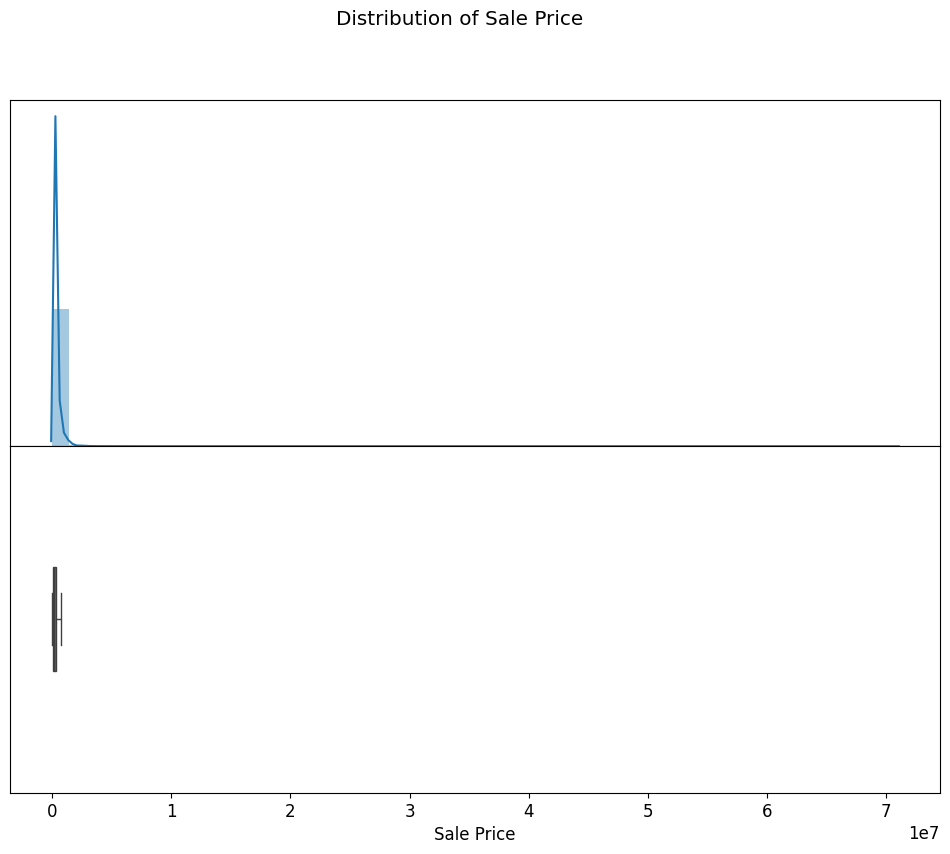

In [7]:
plot_distribution(initial_data, label='Sale Price')

We can see that the data is highly skewed to the right currently, probably because of some extremely expensive houses. To get a clearer view of the distribution, the following cell will examine a more limited range of house prices from [\$0, \$1,000,000]. 

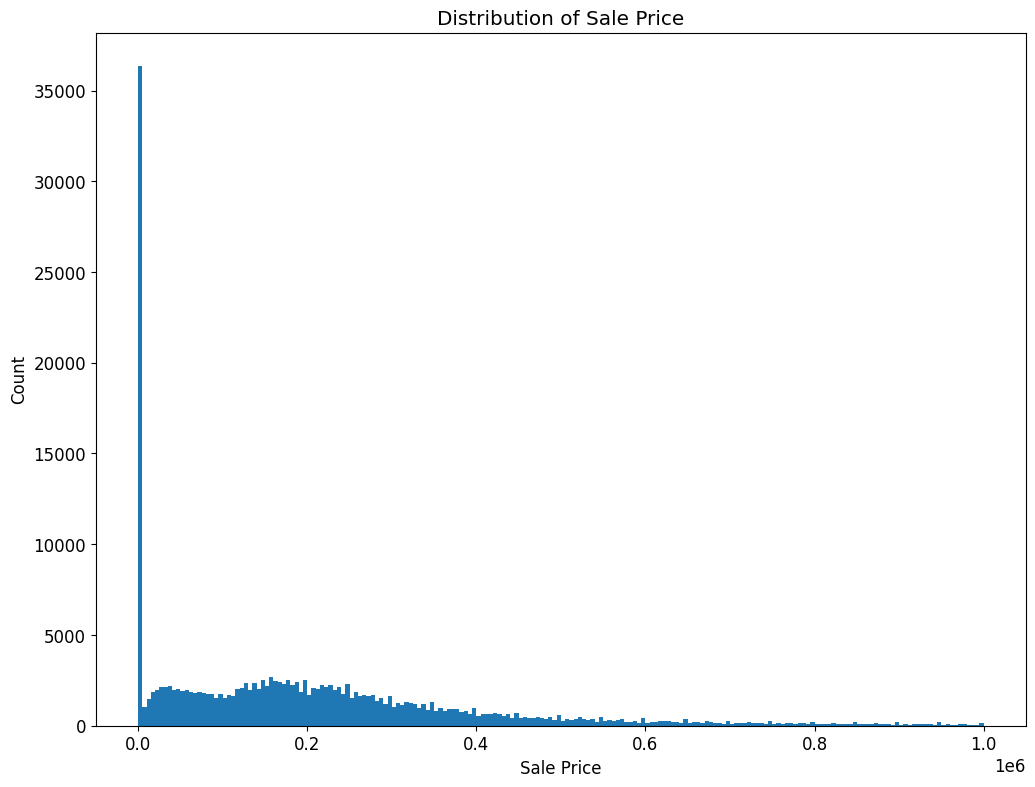

In [8]:
no_right_outliers = initial_data[initial_data['Sale Price'] <= 1000000]['Sale Price']
plt.hist(no_right_outliers, bins=200)
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.title("Distribution of Sale Price")
plt.show()

In [9]:
initial_data['Sale Price'].value_counts()

Sale Price
1          35546
250000      1252
200000      1232
150000      1189
175000      1118
           ...  
1266000        1
127755         1
276185         1
1757000        1
225302         1
Name: count, Length: 14720, dtype: int64

In [10]:
len(initial_data[initial_data['Sale Price'] > 1000000]) / len(initial_data[initial_data['Sale Price'] >= 500])

0.034114520129520334


- `training_data` should contain only households whose price is at least $500.
- `training_data` should contain a new `Log Sale Price` column that contains the log-transformed sale prices.


In [11]:
training_data = (initial_data[initial_data['Sale Price'] >= 500])
training_data['Log Sale Price'] = training_data['Sale Price'].apply(np.log)

Let's create a new distribution plot using the log-transformed sale prices. As a sanity check, we should see that the distribution for `Log Scale Price` is much more uniform.

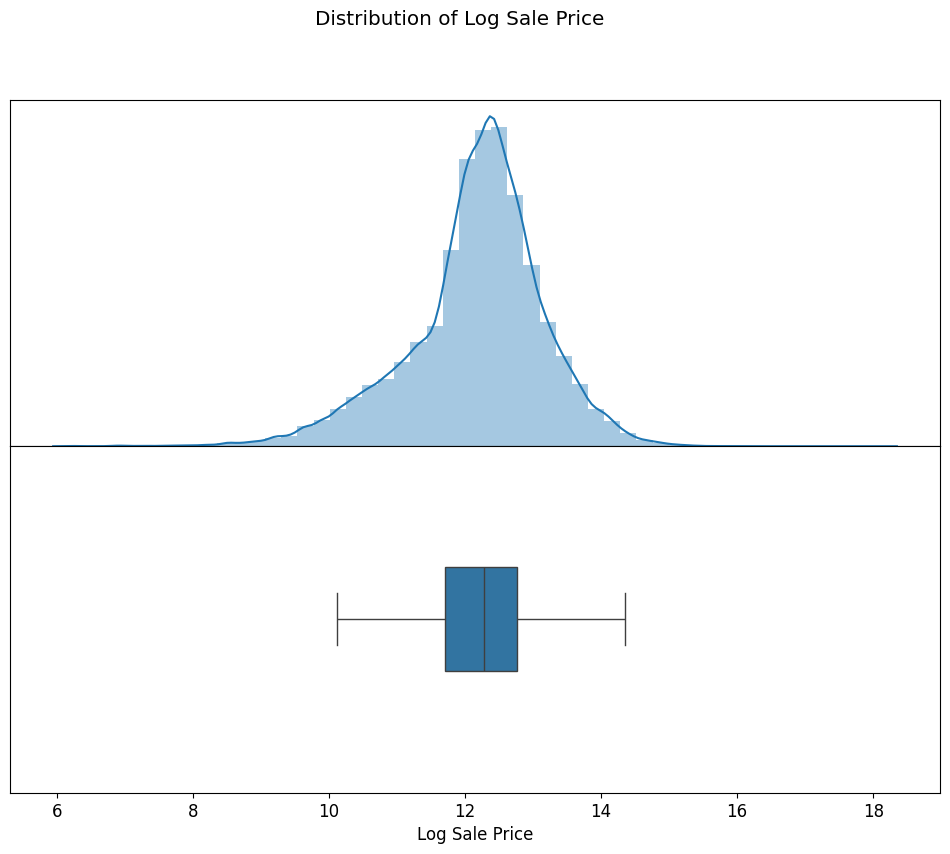

In [12]:
plot_distribution(training_data, label='Log Sale Price');



Next, we want to explore if there is any correlation between `Log Sale Price` and the total area occupied by the property. 

In [13]:
training_data['Log Building Square Feet'] = training_data['Building Square Feet'].apply(np.log)

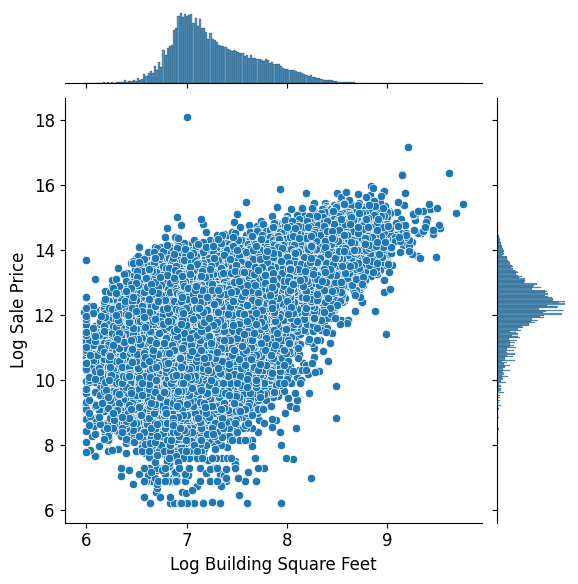

In [14]:
sns.jointplot(data=training_data, x='Log Building Square Feet', y='Log Sale Price')

`remove_outliers` removes outliers from the dataset based on a threshold value of a variable.

In [15]:
def remove_outliers(data, variable, lower=-np.inf, upper=np.inf):
    return data[(data[variable] > lower) & (data[variable] < upper)]



# Feature Engineering




We'll use the `Description` column to extract new useful information.

In [16]:
training_data['Description'][2]

'This property, sold on 02/18/2016, is a one-story houeshold located at 11415 S PRAIRIE AVE.It has a total of 7 rooms, 3 of which are bedrooms, and 1.0 of which are bathrooms.'


The function `add_number_bathrooms(data)` returns a copy of `data` with an additional column called `Bathrooms` that contains the total number of bathrooms for each house. 

In [17]:
def add_total_bathrooms(data):
    with_rooms = data.copy()
    with_rooms['Bathrooms'] = with_rooms['Description'].str.extract(r'(\d+\.\d+) of which are bathrooms').astype('float')
    return with_rooms

training_data = add_total_bathrooms(training_data)

Text(0.5, 1.0, 'Log Sale Price by Number of Bathrooms')

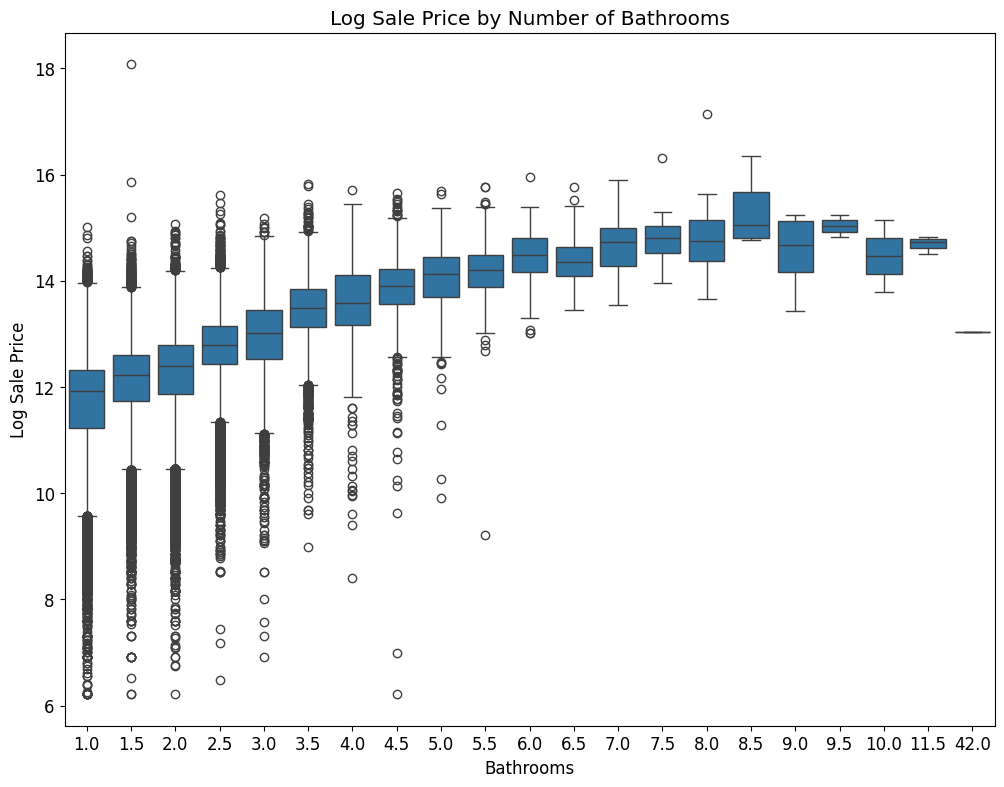

In [18]:
sns.boxplot(data = training_data, x = 'Bathrooms', y = 'Log Sale Price')
plt.title('Log Sale Price by Number of Bathrooms')

<!-- END QUESTION -->

Now, let's take a look at the relationship between neighborhood and sale prices of the houses in our dataset.
Notice that currently we don't have the actual names for the neighborhoods. Instead we will use a similar column, `Neighborhood Code` (which is a numerical encoding of the actual neighborhoods by the Assessment office).



Before creating any visualization, let's quickly inspect how many different neighborhoods we are dealing with.



In [19]:
num_neighborhoods = len(training_data['Neighborhood Code'].unique())
num_neighborhoods

193

In [20]:
def plot_categorical(neighborhoods):
    fig, axs = plt.subplots(nrows=2)

    sns.boxplot(
        x='Neighborhood Code',
        y='Log Sale Price',
        data=neighborhoods,
        ax=axs[0],
    )

    sns.countplot(
        x='Neighborhood Code',
        data=neighborhoods,
        ax=axs[1],
    )

    # Draw median price
    axs[0].axhline(
        y=training_data['Log Sale Price'].median(), 
        color='red',
        linestyle='dotted'
    )

    # Label the bars with counts
    for patch in axs[1].patches:
        x = patch.get_bbox().get_points()[:, 0]
        y = patch.get_bbox().get_points()[1, 1]
        axs[1].annotate(f'{int(y)}', (x.mean(), y), ha='center', va='bottom')

    # Format x-axes
    axs[1].set_xticklabels(axs[1].xaxis.get_majorticklabels(), rotation=90)
    axs[0].xaxis.set_visible(False)

    # Narrow the gap between the plots
    plt.subplots_adjust(hspace=0.01)

Since there are many neighborhoods included in the data, let's narrow it down and look at just 20 of them to avoid overplotting. 

In [21]:
top_20_neighborhood_codes = training_data['Neighborhood Code'].value_counts().sort_values(ascending = False).iloc[:20]
in_top_20_neighborhoods = training_data[training_data['Neighborhood Code'].isin(top_20_neighborhood_codes.index)]

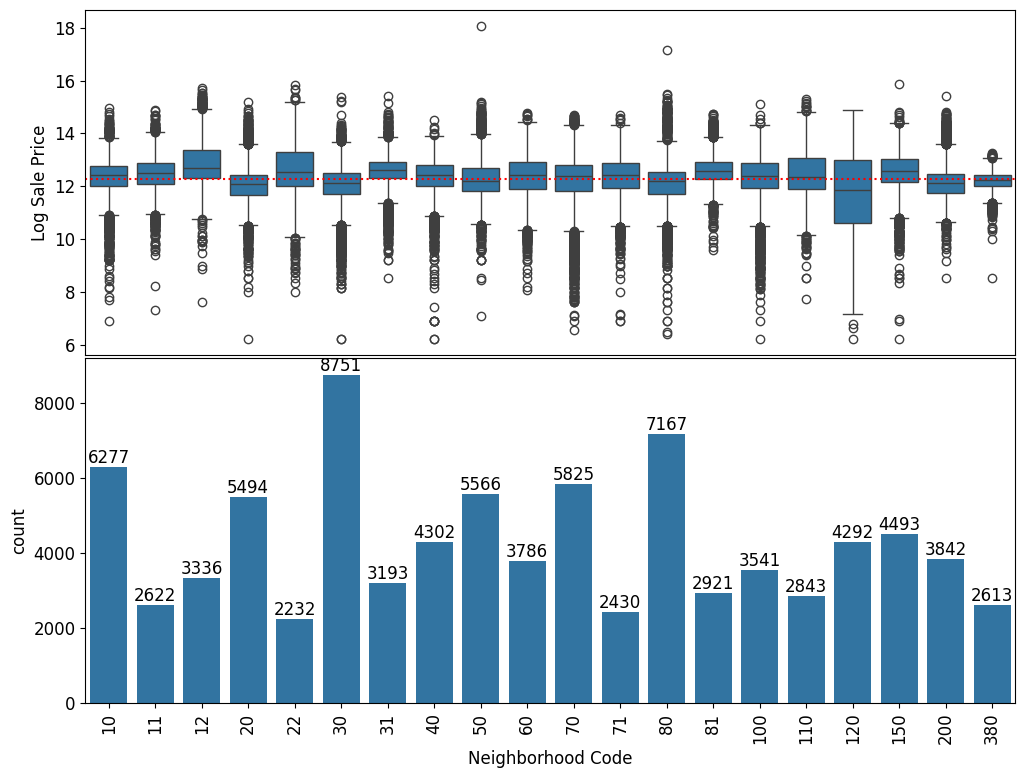

In [22]:
plot_categorical(neighborhoods=in_top_20_neighborhoods)


We can compute how “expensive” each neighborhood is by aggregating the `Log Sale Price`s for all properties in a particular neighborhood using a `metric`, such as the median. We’ll use this `metric` to find the top `n` most expensive neighborhoods.

`find_expensive_neighborhoods` returns a **list** of the neighborhood codes of the **top `n`** most expensive neighborhoods as measured by our choice of aggregating function, `metric`.

For example, calling `find_expensive_neighborhoods(training_data, n=3, metric=np.median)` returns the 3 neighborhood codes with the highest median `Log Sale Price` computed across all properties in those neighborhood codes. 

In [23]:
def find_expensive_neighborhoods(data, n=3, metric=np.median):
    neighborhoods = (training_data[['Neighborhood Code', 'Log Sale Price']]
                     .groupby('Neighborhood Code')
                     .agg(metric)
                     .sort_values('Log Sale Price', ascending = False)
                     .index[0:n]
                    )
    
    # This makes sure the final list contains the generic int type used in Python3, not specific ones used in NumPy.
    return [int(code) for code in neighborhoods]

expensive_neighborhoods = find_expensive_neighborhoods(training_data, 3, np.median)
expensive_neighborhoods

[44, 94, 93]


`add_in_expensive_neighborhood` adds a column to `data` named `in_expensive_neighborhood` that takes on the **integer** value of 1 if a property is part of a neighborhood in `expensive_neighborhoods` and the integer value of 0 if it is not. 



In [24]:
def add_in_expensive_neighborhood(data, expensive_neighborhoods):
    data['in_expensive_neighborhood'] = data['Neighborhood Code'].isin(expensive_neighborhoods).astype(int)
    return data

expensive_neighborhoods = find_expensive_neighborhoods(training_data, 3, np.median)
training_data = add_in_expensive_neighborhood(training_data, expensive_neighborhoods)

Now we will take a closer look at the `Wall Material` feature of the dataset and examine how we can incorporate categorical features into our linear model.



According to `codebook.txt`, we can see that the Assessor's Office uses the following mapping for the numerical values in the `Wall Material` column.
```
Other Heating (Nominal): 

       1    Wood
       2    Masonry
       3    Wood&Masonry
       4    Stucco

```

The function `substitute_wall_material` replaces each numerical value in `Wall Material` with their corresponding heating source. The function returns a new `DataFrame`, it does not modify the existing `DataFrame`.


In [25]:
def substitute_wall_material(data):
    new_data = data.copy()
    new_data['Wall Material'] = new_data['Wall Material'].replace({1:'Wood', 2:'Masonry', 3:'Wood&Masonry', 4:'Stucco'})
    return new_data
    
training_data_mapped = substitute_wall_material(training_data)
training_data_mapped.head()

,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Apartments,Wall Material,Roof Material,Basement,Basement Finish,...,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Town and Neighborhood,Description,Lot Size,Log Sale Price,Log Building Square Feet,Bathrooms,in_expensive_neighborhood
1,13272240180000,202,120,3780.0,71,0.0,Masonry,1.0,1.0,1.0,...,1,1.0,120,71120,"This property, sold on 05/23/2018, is a one-st...",3780.0,12.560244,6.904751,1.0,0
2,25221150230000,202,210,4375.0,70,0.0,Masonry,1.0,2.0,3.0,...,1,1.0,210,70210,"This property, sold on 02/18/2016, is a one-st...",4375.0,9.998798,6.810142,1.0,0
3,10251130030000,203,220,4375.0,17,0.0,Wood&Masonry,1.0,1.0,3.0,...,1,1.0,220,17220,"This property, sold on 07/23/2013, is a one-st...",4375.0,12.323856,7.068172,1.5,0
4,31361040550000,202,120,8400.0,32,0.0,Wood&Masonry,1.0,2.0,3.0,...,1,1.0,120,32120,"This property, sold on 06/10/2016, is a one-st...",8400.0,10.025705,6.855409,1.0,0
6,30314240080000,203,181,10890.0,37,0.0,Wood,1.0,1.0,3.0,...,1,1.0,181,37181,"This property, sold on 10/26/2017, is a one-st...",10890.0,11.512925,7.458186,1.5,0



#### One-Hot-Encoding

Since `Wall Material` is a categorical variable, we will have to one-hot-encode the data. 

The following function `ohe_wall_material` returns a `DataFrame` with the new column one-hot-encoded on the wall material of the household. These new columns have the form `Wall Material_MATERIAL`. The function will return a new `DataFrame` and  not modify the existing `DataFrame`.

We'll use `scikit-learn`’s `OneHotEncoder` to perform the one-hot-encoding. 

In [26]:
from sklearn.preprocessing import OneHotEncoder

def ohe_wall_material(data):
    """
    One-hot-encodes wall material. New columns are of the form "Wall Material_MATERIAL".
    """
    new_data = data.copy()
    ohe = OneHotEncoder(sparse_output = False)
    ohe_data = ohe.fit_transform(new_data[['Wall Material']])
    
    ohe_df = pd.DataFrame(data = ohe_data, columns = ohe.get_feature_names_out(), index = data.index)
    
    
    return new_data.join(ohe_df)
            

training_data_ohe = ohe_wall_material(training_data_mapped)
# This line of code will display only the one-hot-encoded columns in training_data_ohe that 
# have names that begin with “Wall Material_" 
training_data_ohe.filter(regex='^Wall Material_').head(10)

,Wall Material_Masonry,Wall Material_Stucco,Wall Material_Wood,Wall Material_Wood&Masonry
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0
6,0.0,0.0,1.0,0.0
7,0.0,0.0,1.0,0.0
8,1.0,0.0,0.0,0.0
9,0.0,0.0,1.0,0.0
10,0.0,0.0,1.0,0.0
11,1.0,0.0,0.0,0.0
